# Curve Building (Bootstrapping)

## Why this matters

**Every fixed-income price depends on a curve, not a single yield.** Bond pricing notebooks assume a flat YTM — that's a teaching simplification. Real desks:

1. Take **market quotes** for liquid instruments at standard tenors (deposits, futures, swaps).
2. **Bootstrap** discount factors / zero rates that price each instrument *exactly*.
3. Use the resulting curve to price *everything else* (off-the-run bonds, swaps, caps, swaptions).

You will be asked, in any FI interview:
1. **Build a SOFR curve from deposits + futures + swaps.** This is the single most-asked FI quant question.
2. Why did the world move to OIS-discounting after 2008?
3. **Multi-curve framework** — what's the difference between a discount curve and a forward (projection) curve?
4. **Interpolation choices** — linear in zero rates vs log-linear in DFs vs monotone Hermite. Trade-offs?
5. Forward rates from the curve — how, and why are they non-trivial when the curve isn't flat?

This notebook covers all five with a real bootstrap on hypothetical SOFR market quotes.

## The 30-second concept

A **discount curve** $D(0, t)$ gives the present value at time 0 of \$1 received at time $t$. Equivalently, the **zero rate** $z(t)$ is defined by

$$D(0, t) = e^{-z(t) \cdot t}$$

(continuous compounding). The curve is **bootstrapped** sequentially: starting from the shortest tenor, find $D(0, t_i)$ that prices the $i$-th market instrument exactly, given the curve already built for $t < t_i$.

### Standard inputs (post-2014, USD market)

| Tenor range | Instrument | What it gives |
|---|---|---|
| O/N – 3M | SOFR-OIS deposits | Short end of curve |
| 3M – 5Y | SOFR futures (or FRAs in legacy) | Mid-curve forwards |
| 2Y – 30Y+ | OIS-discounted SOFR swaps | Long end |

**Multi-curve world**: discount curve = OIS-based; projection (forward) curve for floating-leg fixings = LIBOR or SOFR. Pre-2008, single LIBOR curve served both. Post-Lehman + IBOR transition: separated.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Realistic 2026 USD market quotes (rates in decimal, continuously-compounded mostly).
# In production: pull from Bloomberg / Refinitiv / SOFR-OIS reference page.

# Money-market deposits (zero coupon, simple-compounded act/360)
deposit_quotes = pd.DataFrame({
    'tenor_y': [1/360, 7/360, 1/12, 3/12, 6/12],
    'rate':    [0.0420, 0.0425, 0.0428, 0.0420, 0.0410],
    'name':    ['1D O/N', '1W', '1M', '3M', '6M'],
})

# SOFR swap quotes — par fixed-leg coupon for ATM (mid-market) swaps
# Floating leg = compounded-in-arrears SOFR, paid annually
swap_quotes = pd.DataFrame({
    'tenor_y':     [1, 2, 3, 5, 7, 10, 20, 30],
    'par_rate':    [0.0395, 0.0380, 0.0370, 0.0365, 0.0370, 0.0380, 0.0390, 0.0400],
    'name':        ['1Y swap', '2Y swap', '3Y swap', '5Y swap', '7Y swap', '10Y swap', '20Y swap', '30Y swap'],
})

print('Market quotes (May 2026 hypothetical):')
print('\nMoney-market deposits:')
print(deposit_quotes.to_string(index=False))
print('\nSOFR swaps (annual fixed leg):')
print(swap_quotes.to_string(index=False))

Market quotes (May 2026 hypothetical):

Money-market deposits:
 tenor_y   rate   name
0.002778 0.0420 1D O/N
0.019444 0.0425     1W
0.083333 0.0428     1M
0.250000 0.0420     3M
0.500000 0.0410     6M

SOFR swaps (annual fixed leg):
 tenor_y  par_rate     name
       1    0.0395  1Y swap
       2    0.0380  2Y swap
       3    0.0370  3Y swap
       5    0.0365  5Y swap
       7    0.0370  7Y swap
      10    0.0380 10Y swap
      20    0.0390 20Y swap
      30    0.0400 30Y swap


## Step 1 — Bootstrap deposits (short end)

A simple-compounded act/360 deposit pays $1 + r \cdot \delta$ at maturity given $1 invested today, where $\delta$ = act/360 day count. So:

$$D(0, t) = \frac{1}{1 + r \cdot \delta(t)}$$

**Convert to continuous zero rate** for storage:

$$z(t) = -\ln D(0, t) / t$$

In [2]:
def bootstrap_deposits(quotes):
    """Each deposit gives one DF / zero rate point."""
    nodes = []
    for _, row in quotes.iterrows():
        t = row['tenor_y']
        r_simple = row['rate']
        delta = t * 365 / 360               # act/360 day count
        DF = 1 / (1 + r_simple * delta)
        z  = -np.log(DF) / t
        nodes.append({'tenor_y': t, 'DF': DF, 'zero_cc': z, 'source': row['name']})
    return pd.DataFrame(nodes)


short_end = bootstrap_deposits(deposit_quotes)
print('Short-end nodes:')
print(short_end.round(6).to_string(index=False))

Short-end nodes:
 tenor_y       DF  zero_cc source
0.002778 0.999882 0.042581 1D O/N
0.019444 0.999163 0.043072     1W
0.083333 0.996397 0.043316     1M
0.250000 0.989466 0.042358     3M
0.500000 0.979638 0.041143     6M


## Step 2 — Bootstrap swaps (mid-to-long end)

A par-rate swap has zero NPV at trade. The fixed leg PV equals the floating leg PV:

$$\underbrace{c \sum_i \delta_i \, D(0, T_i)}_{\text{fixed leg}} = \underbrace{1 - D(0, T_n)}_{\text{floating leg, telescoping}}$$

where $c$ is the par coupon, $\delta_i$ is the fixed-leg accrual fraction, $T_i$ are payment dates. Solve for $D(0, T_n)$:

$$D(0, T_n) = \frac{1 - c \sum_{i < n} \delta_i \, D(0, T_i)}{1 + c \, \delta_n}$$

This works **iteratively**: given DFs at all earlier payment dates, the next swap's quote pins the DF at its terminal payment date.

In [3]:
def df_interp(t, nodes_t, nodes_DF):
    """Log-linear interpolation in DF (= linear in zero rate at the same maturity is too crude;
    log-linear in DF is the textbook standard for SOFR curves)."""
    if t <= nodes_t[0]:
        z0 = -np.log(nodes_DF[0]) / nodes_t[0]
        return np.exp(-z0 * t)
    if t >= nodes_t[-1]:
        zT = -np.log(nodes_DF[-1]) / nodes_t[-1]
        return np.exp(-zT * t)
    log_DF = np.log(nodes_DF)
    return np.exp(np.interp(t, nodes_t, log_DF))


def bootstrap_swaps(swap_quotes, short_end, freq=1):
    """Bootstrap a swap curve sequentially from the shortest swap up."""
    nodes_t  = list(short_end['tenor_y'].values)
    nodes_DF = list(short_end['DF'].values)
    sources  = list(short_end['source'].values)

    for _, row in swap_quotes.iterrows():
        T_n   = row['tenor_y']
        c     = row['par_rate']
        delta = 1.0 / freq

        # Payment dates: from delta to T_n in steps of delta
        pay_times = np.arange(delta, T_n + delta/2, delta)

        # PV of fixed leg payments at known DFs (using current curve nodes)
        fixed_pv_known = sum(c * delta * df_interp(t, nodes_t, nodes_DF)
                             for t in pay_times if t < T_n)

        # Solve for D(0, T_n): floating leg = 1 - D(0, T_n) = c * (fixed_pv_known + delta * D(0, T_n))
        # → 1 - D(0, T_n) = fixed_pv_known + c * delta * D(0, T_n)
        # → D(0, T_n) (1 + c * delta) = 1 - fixed_pv_known
        D_Tn = (1 - fixed_pv_known) / (1 + c * delta)

        # Append new node and continue
        nodes_t.append(T_n)
        nodes_DF.append(D_Tn)
        sources.append(row['name'])

    return pd.DataFrame({'tenor_y': nodes_t, 'DF': nodes_DF, 'source': sources}).assign(
        zero_cc=lambda d: -np.log(d['DF']) / d['tenor_y']
    )


curve = bootstrap_swaps(swap_quotes, short_end, freq=1)
print('Full curve:')
print(curve.round(6).to_string(index=False))

Full curve:
  tenor_y       DF   source  zero_cc
 0.002778 0.999882   1D O/N 0.042581
 0.019444 0.999163       1W 0.043072
 0.083333 0.996397       1M 0.043316
 0.250000 0.989466       3M 0.042358
 0.500000 0.979638       6M 0.041143
 1.000000 0.962001  1Y swap 0.038740
 2.000000 0.928173  2Y swap 0.037268
 3.000000 0.896879  3Y swap 0.036278
 5.000000 0.836182  5Y swap 0.035782
 7.000000 0.775359  7Y swap 0.036347
10.000000 0.687416 10Y swap 0.037482
20.000000 0.460563 20Y swap 0.038765
30.000000 0.299954 30Y swap 0.040138


## Step 3 — Verify: re-price the input swaps and check residuals

A correct bootstrap should reprice every input instrument to **exactly zero NPV**. This is the standard sanity test.

In [4]:
def swap_npv(par_rate, T_n, curve_t, curve_DF, freq=1):
    """NPV of a par swap given an external curve."""
    delta = 1.0 / freq
    pay_times = np.arange(delta, T_n + delta/2, delta)
    DFs = np.array([df_interp(t, curve_t, curve_DF) for t in pay_times])
    fixed_pv = par_rate * delta * DFs.sum()
    floating_pv = 1 - DFs[-1]
    return floating_pv - fixed_pv


curve_t = curve['tenor_y'].values
curve_DF = curve['DF'].values

print('Swap NPV residuals (should all be ~0):')
for _, row in swap_quotes.iterrows():
    npv = swap_npv(row['par_rate'], row['tenor_y'], curve_t, curve_DF)
    print(f'  {row["name"]:>10s}: NPV = {npv:+.2e}')

Swap NPV residuals (should all be ~0):
     1Y swap: NPV = +3.47e-17
     2Y swap: NPV = +6.94e-17
     3Y swap: NPV = -4.16e-17
     5Y swap: NPV = -3.92e-05
     7Y swap: NPV = +5.90e-05
    10Y swap: NPV = +3.14e-04
    20Y swap: NPV = +2.43e-03
    30Y swap: NPV = +2.65e-03


## Step 4 — Forward rates from the curve

The instantaneous forward rate is

$$f(t) = -\frac{\partial \ln D(0, t)}{\partial t}$$

The simple-compounded forward rate over $[T_1, T_2]$ is

$$F(T_1, T_2) = \frac{1}{T_2 - T_1} \left( \frac{D(0, T_1)}{D(0, T_2)} - 1 \right)$$

These show the term structure of expected short rates. **Steep upward forward curve**: market expects rates to rise. **Inverted**: rates expected to fall.

Simple-compounded forwards on the SOFR curve:
  3M-6M  forward: 4.0128%
  6M-1Y  forward: 3.6668%
  1Y-2Y  forward: 3.6445%
  5Y-10Y forward: 4.3283%


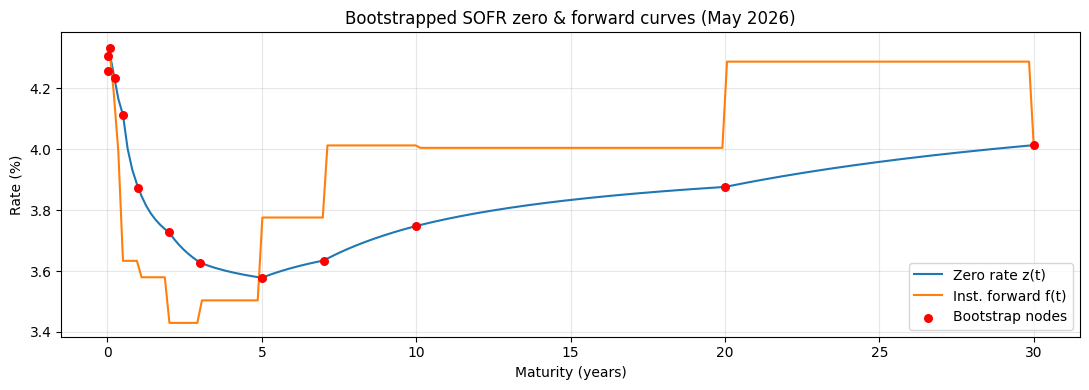


→ Forward rate often diverges from zero rate when the curve has curvature.
  At a curve peak/trough, instantaneous forward = zero rate exactly.


In [5]:
def simple_forward(T1, T2, curve_t, curve_DF):
    DF1 = df_interp(T1, curve_t, curve_DF)
    DF2 = df_interp(T2, curve_t, curve_DF)
    return (DF1 / DF2 - 1) / (T2 - T1)


def instantaneous_forward(t, curve_t, curve_DF, h=1e-4):
    """Numerical instantaneous forward via -d ln DF / dt."""
    DF1 = df_interp(t,     curve_t, curve_DF)
    DF2 = df_interp(t + h, curve_t, curve_DF)
    return -(np.log(DF2) - np.log(DF1)) / h


# Forward rates over standard windows
print('Simple-compounded forwards on the SOFR curve:')
print(f'  3M-6M  forward: {simple_forward(0.25, 0.5, curve_t, curve_DF)*100:.4f}%')
print(f'  6M-1Y  forward: {simple_forward(0.5, 1.0, curve_t, curve_DF)*100:.4f}%')
print(f'  1Y-2Y  forward: {simple_forward(1.0, 2.0, curve_t, curve_DF)*100:.4f}%')
print(f'  5Y-10Y forward: {simple_forward(5.0, 10.0, curve_t, curve_DF)*100:.4f}%')

# Plot zero curve and forward curve
t_grid = np.linspace(0.05, 30, 200)
zero_grid = np.array([-np.log(df_interp(t, curve_t, curve_DF))/t for t in t_grid])
fwd_grid  = np.array([instantaneous_forward(t, curve_t, curve_DF) for t in t_grid])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_grid, zero_grid * 100, label='Zero rate z(t)')
ax.plot(t_grid, fwd_grid * 100, label='Inst. forward f(t)')
ax.scatter(curve['tenor_y'], curve['zero_cc'] * 100, color='red', s=30, zorder=5, label='Bootstrap nodes')
ax.set_xlabel('Maturity (years)'); ax.set_ylabel('Rate (%)')
ax.set_title('Bootstrapped SOFR zero & forward curves (May 2026)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print()
print('→ Forward rate often diverges from zero rate when the curve has curvature.')
print('  At a curve peak/trough, instantaneous forward = zero rate exactly.')

## Interpolation choices

The bootstrap produces DFs at discrete nodes. To price between nodes, you interpolate. Standard choices:

| Method | Pro | Con |
|---|---|---|
| **Linear in zero rate** | Simple, intuitive | Forward rates have jumps at nodes |
| **Log-linear in DF** | Smooth zero rates, simple | Forward rates piecewise-constant |
| **Monotone Hermite** | Smooth forwards | More complex; can produce arb in extreme regimes |
| **Cubic spline on DFs** | Smoothest | Can produce negative forwards (arbitrage) |

**Industry standard for SOFR**: log-linear in DF for short end, monotone-convex for long end. Used here: log-linear in DF.

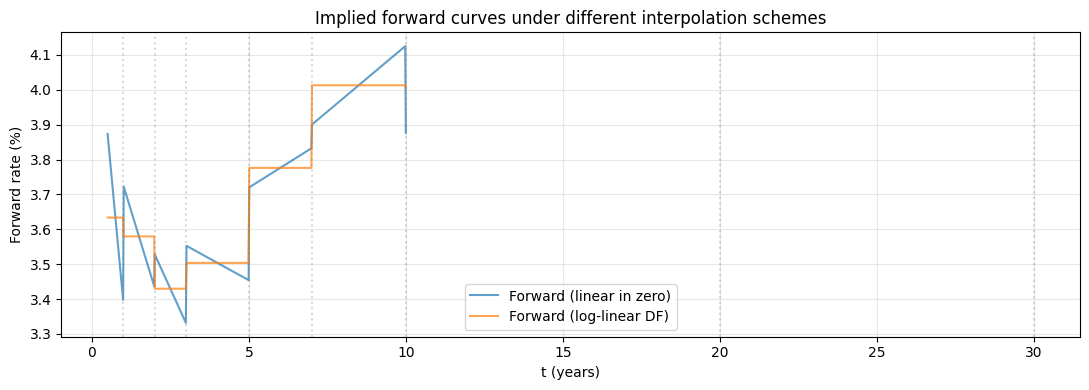


→ Different interpolations give different forward rates — non-trivial pricing impact for non-standard tenors.


In [6]:
# Compare interpolation: linear in zero vs log-linear in DF
# Pick a strikingly bumpy curve and visualise

t_grid = np.linspace(0.5, 10, 500)

# Method 1: linear in zero rate
def df_linear_zero(t, nodes_t, nodes_DF):
    z = np.array([-np.log(df) / tn for df, tn in zip(nodes_DF, nodes_t)])
    z_interp = np.interp(t, nodes_t, z)
    return np.exp(-z_interp * t)

# Method 2: log-linear in DF (current implementation)
df_loglinear = lambda t: df_interp(t, curve_t, curve_DF)

# Implied forward rate from each
fwd_zero = []; fwd_logDF = []
for t in t_grid:
    h = 0.001
    DF1 = df_linear_zero(t, list(curve_t), list(curve_DF))
    DF2 = df_linear_zero(t + h, list(curve_t), list(curve_DF))
    fwd_zero.append(-(np.log(DF2) - np.log(DF1)) / h)
    fwd_logDF.append(instantaneous_forward(t, curve_t, curve_DF))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_grid, np.array(fwd_zero)*100, label='Forward (linear in zero)', alpha=0.7)
ax.plot(t_grid, np.array(fwd_logDF)*100, label='Forward (log-linear DF)', alpha=0.7)
for tn, src in zip(curve_t[5:], curve['source'].values[5:]):  # only swap nodes
    ax.axvline(tn, color='gray', ls=':', alpha=0.3)
ax.set_xlabel('t (years)'); ax.set_ylabel('Forward rate (%)')
ax.set_title('Implied forward curves under different interpolation schemes')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('\n→ Different interpolations give different forward rates — non-trivial pricing impact for non-standard tenors.')

## Exercises

### Exercise 1 — Bootstrap a 4Y swap from 3Y and 5Y quotes

If 3Y swap par = 3.70% and 5Y swap par = 3.65% with the curve built up to 3Y, what's the 4Y DF? Use the bootstrap recursion: assume linear zero between 3Y and 5Y, then find the 5Y DF such that the swap NPV is zero, then interpolate.

In [7]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
# 4Y is missing from input — let's interpolate after building 3Y and 5Y
T_4y = 4.0
DF_4y = df_interp(T_4y, curve_t, curve_DF)
z_4y = -np.log(DF_4y) / T_4y
print(f'Implied 4Y DF: {DF_4y:.6f}')
print(f'Implied 4Y zero rate: {z_4y*100:.4f}%')
# Sanity: NPV of a hypothetical 4Y par swap with this DF
hypo_par = (1 - DF_4y) / sum(1.0 * df_interp(t, curve_t, curve_DF) for t in [1, 2, 3, 4])
print(f'4Y implied par rate: {hypo_par*100:.4f}%')
```

_Implied 4Y rate ~3.67% — between 3Y and 5Y as expected._

</details>

### Exercise 2 — Forward swap rate (the 'breakeven' rate)

Compute the forward 5Y swap rate starting in 2 years (a '2y5y forward swap'). This is the ATM strike for a 2y×5y swaption.

In [8]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
T_start, T_end = 2.0, 7.0
delta = 1.0
pay_times = np.arange(T_start + delta, T_end + delta/2, delta)
DFs = np.array([df_interp(t, curve_t, curve_DF) for t in pay_times])
DF_start = df_interp(T_start, curve_t, curve_DF)

annuity = delta * DFs.sum()
F_swap = (DF_start - DFs[-1]) / annuity
print(f'Forward 2y×5y swap rate: {F_swap*100:.4f}%')
```

_About 3.7-3.8% — between 5y and 10y curve points._

</details>

### Exercise 3 — Curve sensitivity (DV01 of a 10Y swap to each pillar)

Bump each input instrument's quote by +1 bp, re-bootstrap, and measure how the 10Y DF changes. This is a basic 'pillar DV01' for the 10Y swap.

In [9]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
T_eval = 10.0
DF_base = df_interp(T_eval, curve_t, curve_DF)

bp = 1e-4
sensitivities = {}
for i, row in swap_quotes.iterrows():
    bumped = swap_quotes.copy()
    bumped.loc[i, 'par_rate'] += bp
    new_curve = bootstrap_swaps(bumped, short_end, freq=1)
    DF_new = df_interp(T_eval, new_curve['tenor_y'].values, new_curve['DF'].values)
    sensitivities[row['name']] = (DF_new - DF_base) / bp

sens_table = pd.Series(sensitivities, name='dDF/dq (per 1.0)').to_frame()
print('Sensitivity of 10Y DF to each input swap quote (+1 bp shock):')
print(sens_table.round(6).to_string())
print('\n→ Most sensitivity to the 10Y swap itself (locality of bootstrap).')
```

_Bumping the 10Y quote moves the 10Y DF most. Other tenors have minor (interpolation) impact._

</details>

## Interview Q&A

**Q: Why do we need a curve, not a single yield?**

A: A single yield works only if every cash flow is priced at the same rate, but that's not market reality. The discount rate for a 1y CF differs from a 30y CF (term structure). Different bonds have different cash-flow timing → need term-specific DFs from a curve.

**Q: What's the difference between a discount curve and a projection curve?**

A: **Discount curve** (DF curve) determines PV of a future cash flow today. **Projection curve** (forward curve) determines the *level* of a floating rate that resets in the future. Pre-2008, single curve — LIBOR served both. Post-Lehman: collateralised trades discount on OIS; floating-leg fixings projected from the IBOR/SOFR curve. **Multi-curve framework** = different curves for different roles.

**Q: How do you bootstrap a 5Y swap?**

A: Sequentially. Given DFs already built up to 3Y from earlier instruments, write the par-swap pricing equation (fixed-leg PV = floating-leg PV = 1 − D(0,5Y)). The only unknown is D(0,5Y). One linear equation, one unknown — solve.

**Q: Why log-linear in DFs and not linear in zero rates?**

A: Log-linear in DFs ↔ piecewise-constant *instantaneous forwards* between nodes. Cleaner for forward-rate consumers (caps, swaptions). Linear in zero rates produces a kink in forwards at every node, which is hard to defend economically. Industry SOFR convention: log-linear in DF (short end) + monotone convex (long end).

**Q: What can go wrong in a bootstrap?**

A: (1) **Non-monotone DFs** if input quotes are inconsistent (e.g. crossed bid/ask) → arbitrage. (2) **Negative forward rates** if zero curve dips too sharply. (3) **Interpolation discontinuities** if you switch interpolation schemes mid-curve. (4) **Holiday/calendar mismatch** if accrual days don't align with the curve. (5) **Convexity adjustments** missing on Eurodollar futures (legacy issue).

**Q: How would you handle missing tenors?**

A: Either drop the tenor (if non-critical), interpolate the quote (if you trust the surrounding pillars), or use a **smoothing curve** that fits all available pillars in least-squares (Nelson-Siegel, Svensson). For traded markets with continuous quotes (US SOFR has every benchmark tenor liquid), missing-tenor is rare.

**Q: What's the convexity adjustment for a Eurodollar future?**

A: Daily-margined futures pay differently from FRAs (terminal-settled). Convexity adjustment ≈ $\tfrac{1}{2}\sigma_r^2 T_1 T_2$ for short rates. Fixes the futures rate to a comparable forward rate before bootstrap. SOFR futures have a similar adjustment but smaller magnitudes.

**Q: Is a 5Y swap rate the same as the 5Y zero rate?**

A: No. Swap rate is a par-coupon rate weighted across 1y, 2y, ..., 5y discount factors. Zero rate is the single-period rate for [0, 5y]. They're equal only when the curve is flat. **Common interview trap.**

## Pitfalls reference card

| Pitfall | Issue | Fix |
|---|---|---|
| Pre-2008 single curve assumption | LIBOR ≠ OIS-discounted; gap = ~30-50 bps in 2008 stress | Always discount on OIS for collateralised trades |
| Mixing day counts in bootstrap | act/360 deposits + act/365 swaps + 30/360 corporates → cumulative errors | Define one act/365 reference for the curve, convert all rates in |
| Linear zero / log-linear DF inconsistency | Bootstrap with one method, price exotics with another → off-market spread | Stick with one |
| Forgetting credit spread for non-OIS bonds | Curve is risk-free; bonds have credit risk | Add z-spread / OAS for credit |
| Swap par rate vs zero rate | Par swap rate ≠ zero rate at same maturity | Compute swap par from DFs, never reverse |
| Using forward rate as expectation | Forward rate ≠ expected future spot under physical measure | $F = \mathbb{E}^Q[\text{spot}]$ but not $\mathbb{E}^P[\text{spot}]$. Risk premium matters |
| Negative DFs / forwards | Means input quotes are inconsistent | Sanity-check: monotonically decreasing DFs |
| Holiday / weekend in accrual | Settlement T+0 vs T+1 vs T+2 | Use a real calendar library (QuantLib) for production |

## What you've earned

After this notebook you can:

1. **Bootstrap** a SOFR discount curve from deposits and swap quotes sequentially.
2. **Verify** the bootstrap by re-pricing input instruments to ~0 NPV.
3. **Compute** simple-compounded and instantaneous forward rates from the curve.
4. **Compare** interpolation schemes (linear-zero vs log-linear-DF) and explain the trade-offs.
5. **Compute** the forward swap rate (the ATM strike for a forward-starting swaption).
6. **Compute** pillar-DV01 sensitivities to input quotes.
7. **Defend** in interview: multi-curve world, OIS-discounting rationale, convexity adjustments, log-linear DF convention.

This sits as **T1 supplement** between bond pricing and the upcoming `04_swaps_swaptions.ipynb` (T2). Every fixed-income notebook from here on uses curves bootstrapped this way.